# 02 — Exploratory Data Analysis dengan Spark

Notebook ini membaca data dari MinIO (raw zone) dan melakukan eksplorasi awal menggunakan PySpark sebelum masuk ke tahap data mining.

## 1. Setup SparkSession

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

import sys
sys.path.insert(0, "/home/jovyan/work")

from analysis.spark_session import create_spark_session
spark = create_spark_session("02 - EDA")
print(f"Spark version: {spark.version}")

Spark version: 3.5.0


## 2. Baca Data dari MinIO

In [2]:
BUCKET = "datalake"

# Gunakan wildcard untuk membaca semua partisi tanggal
df_customers = spark.read.csv(f"s3a://{BUCKET}/raw/rdbms/customers/*/customers_from_db.csv", header=True, inferSchema=True)
df_orders    = spark.read.csv(f"s3a://{BUCKET}/raw/rdbms/orders/*/orders_from_db.csv",       header=True, inferSchema=True)
df_products  = spark.read.csv(f"s3a://{BUCKET}/raw/xlsx/products/*/products_from_xlsx.csv",  header=True, inferSchema=True)

print(f"customers : {df_customers.count()} baris")
print(f"orders    : {df_orders.count()} baris")
print(f"products  : {df_products.count()} baris")

customers : 30 baris
orders    : 63 baris
products  : 15 baris


## 3. Schema & Sample Data

In [3]:
df_customers.printSchema()
df_customers.show(5)

root
 |-- customer_id: integer (nullable = true)
 |-- customer_name: string (nullable = true)
 |-- city: string (nullable = true)
 |-- age: integer (nullable = true)
 |-- signup_date: date (nullable = true)
 |-- source_type: string (nullable = true)
 |-- ingestion_time: timestamp (nullable = true)

+-----------+-------------+--------+---+-----------+-----------+--------------------+
|customer_id|customer_name|    city|age|signup_date|source_type|      ingestion_time|
+-----------+-------------+--------+---+-----------+-----------+--------------------+
|          1|         Andi|  Malang| 21| 2024-01-10|      rdbms|2026-03-27 15:49:...|
|          2|         Budi|  Blitar| 22| 2024-02-11|      rdbms|2026-03-27 15:49:...|
|          3|        Citra|Surabaya| 20| 2024-03-12|      rdbms|2026-03-27 15:49:...|
|          4|         Dewi|  Kediri| 23| 2024-04-13|      rdbms|2026-03-27 15:49:...|
|          5|          Eko| Jakarta| 25| 2024-01-15|      rdbms|2026-03-27 15:49:...|
+-----------

In [4]:
df_orders.printSchema()
df_orders.show(5)

root
 |-- order_id: integer (nullable = true)
 |-- customer_id: integer (nullable = true)
 |-- product_id: integer (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- order_date: date (nullable = true)
 |-- source_type: string (nullable = true)
 |-- ingestion_time: timestamp (nullable = true)

+--------+-----------+----------+--------+----------+-----------+--------------------+
|order_id|customer_id|product_id|quantity|order_date|source_type|      ingestion_time|
+--------+-----------+----------+--------+----------+-----------+--------------------+
|       1|          1|         1|       1|2024-01-15|      rdbms|2026-03-27 15:49:...|
|       2|          1|        14|       1|2024-01-15|      rdbms|2026-03-27 15:49:...|
|       3|          1|        15|       1|2024-01-15|      rdbms|2026-03-27 15:49:...|
|       4|          3|         1|       1|2024-03-15|      rdbms|2026-03-27 15:49:...|
|       5|          3|        14|       1|2024-03-15|      rdbms|2026-03-27 15:49:..

In [5]:
df_products.printSchema()
df_products.show(5)

root
 |-- product_id: integer (nullable = true)
 |-- product_name: string (nullable = true)
 |-- category: string (nullable = true)
 |-- price: integer (nullable = true)
 |-- stock: integer (nullable = true)
 |-- source_type: string (nullable = true)
 |-- ingestion_time: timestamp (nullable = true)

+----------+--------------------+----------+-------+-----+-----------+--------------------+
|product_id|        product_name|  category|  price|stock|source_type|      ingestion_time|
+----------+--------------------+----------+-------+-----+-----------+--------------------+
|         1|Laptop ASUS VivoBook|Elektronik|8500000|   15|       xlsx|2026-03-27 15:49:...|
|         2|Smartphone Samsun...|Elektronik|4200000|   30|       xlsx|2026-03-27 15:49:...|
|         3|Headphone Sony WH...|Elektronik|3800000|   20|       xlsx|2026-03-27 15:49:...|
|         4|   Kaos Polos Cotton|   Pakaian|  75000|  100|       xlsx|2026-03-27 15:49:...|
|         5| Jaket Hoodie Fleece|   Pakaian| 250000|   

## 4. Statistik Deskriptif

In [6]:
print("=== Statistik Customers ===")
df_customers.describe("age").show()

print("=== Statistik Orders ===")
df_orders.describe("quantity").show()

print("=== Statistik Products ===")
df_products.describe("price", "stock").show()

=== Statistik Customers ===
+-------+------------------+
|summary|               age|
+-------+------------------+
|  count|                30|
|   mean|26.166666666666668|
| stddev| 4.962503076231711|
|    min|                19|
|    max|                38|
+-------+------------------+

=== Statistik Orders ===
+-------+------------------+
|summary|          quantity|
+-------+------------------+
|  count|                63|
|   mean|1.4126984126984128|
| stddev|0.8544932592822077|
|    min|                 1|
|    max|                 5|
+-------+------------------+

=== Statistik Products ===
+-------+------------------+-----------------+
|summary|             price|            stock|
+-------+------------------+-----------------+
|  count|                15|               15|
|   mean|1326233.3333333333|             90.0|
| stddev| 2385084.446443494|125.0714081749188|
|    min|              3500|               15|
|    max|           8500000|              500|
+-------+-----------

## 5. Distribusi per Kolom Kategorik

In [7]:
print("=== Distribusi Kota ===")
df_customers.groupBy("city").count().orderBy("count", ascending=False).show()

print("=== Distribusi Kategori Produk ===")
df_products.groupBy("category").count().orderBy("count", ascending=False).show()

=== Distribusi Kota ===
+----------+-----+
|      city|count|
+----------+-----+
|   Jakarta|    4|
|    Malang|    4|
|  Surabaya|    4|
|   Bandung|    4|
|  Makassar|    3|
|  Semarang|    3|
|     Medan|    3|
|Yogyakarta|    3|
|    Kediri|    1|
|    Blitar|    1|
+----------+-----+

=== Distribusi Kategori Produk ===
+---------------+-----+
|       category|count|
+---------------+-----+
|     Elektronik|    5|
|        Makanan|    3|
|        Pakaian|    3|
|Peralatan Rumah|    2|
|       Olahraga|    2|
+---------------+-----+



## 6. Feature Engineering — Fitur Pelanggan

In [8]:
from analysis.preprocessing import build_customer_features

df_features = build_customer_features(df_customers, df_orders, df_products)
df_features.show(10)
df_features.describe("age", "total_orders", "total_spend").show()

+-----------+-------------+----------+---+------------+-----------+-------------------+-------------+
|customer_id|customer_name|      city|age|total_orders|total_spend|avg_spend_per_order|is_high_value|
+-----------+-------------+----------+---+------------+-----------+-------------------+-------------+
|          1|         Andi|    Malang| 21|           4|    9545000|          2386250.0|            1|
|          2|         Budi|    Blitar| 22|           2|    8000000|          4000000.0|            1|
|          3|        Citra|  Surabaya| 20|           2|    8880000|          4440000.0|            1|
|          4|         Dewi|    Kediri| 23|           2|    8000000|          4000000.0|            1|
|          5|          Eko|   Jakarta| 25|           3|   12920000|         4306666.67|            1|
|          6|         Fani|   Bandung| 19|           2|     770000|           385000.0|            1|
|          7|       Gilang|Yogyakarta| 28|           1|     320000|           3200

## 7. Visualisasi (Pandas)

Konversi ke Pandas untuk visualisasi karena dataset kecil.

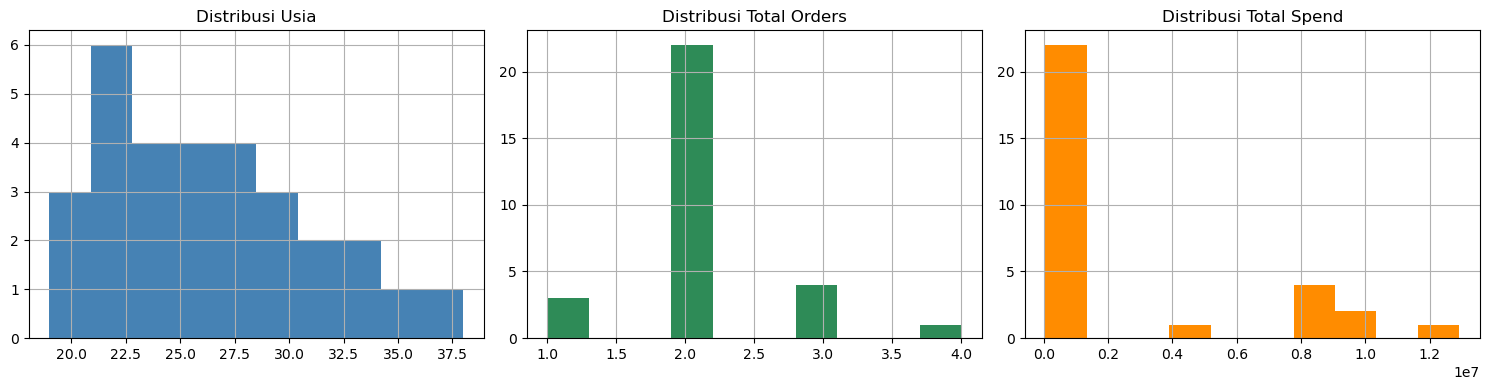

In [9]:
import matplotlib.pyplot as plt
import pandas as pd

pdf = df_features.toPandas()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
pdf["age"].hist(bins=10, ax=axes[0], color="steelblue")
axes[0].set_title("Distribusi Usia")

pdf["total_orders"].hist(bins=10, ax=axes[1], color="seagreen")
axes[1].set_title("Distribusi Total Orders")

pdf["total_spend"].hist(bins=10, ax=axes[2], color="darkorange")
axes[2].set_title("Distribusi Total Spend")

plt.tight_layout()
plt.show()

## 8. Simpan Fitur ke MinIO (processed zone)

In [12]:
df_features.write.mode("overwrite").option("header", True).csv(f"s3a://{BUCKET}/processed/customer_features/")
print("Fitur pelanggan berhasil disimpan ke processed zone.")

Fitur pelanggan berhasil disimpan ke processed zone.
